In [41]:
import sys
print(sys.executable)

c:\Users\Dell 7490\BigDataProject\venv\Scripts\python.exe


In [42]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Student Performance Prediction").getOrCreate()
print("Spark Version:", spark.version)

Spark Version: 4.1.1


In [83]:
# Clean Output
from IPython.display import display
import pandas as pd

pd.set_option('display.max_columns', None)

def show_df(df, n=5):
    display(df.toPandas().head(n))

In [84]:
df = spark.read.csv(
    "dataset/StudentsPerformance.csv",
    header=True,
    inferSchema=True
)

show_df(df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [44]:
df.printSchema()

root
 |-- gender: string (nullable = true)
 |-- race/ethnicity: string (nullable = true)
 |-- parental level of education: string (nullable = true)
 |-- lunch: string (nullable = true)
 |-- test preparation course: string (nullable = true)
 |-- math score: integer (nullable = true)
 |-- reading score: integer (nullable = true)
 |-- writing score: integer (nullable = true)



In [45]:
print("Rows:", df.count())
print("Columns:", df.columns)

Rows: 1000
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [86]:
# Data Cleaning Step
show_df(df.dropna())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [88]:
#Create Average Score
from pyspark.sql.functions import col

df = df.withColumn(
    "average_score",
    (col("math score") + col("reading score") + col("writing score")) / 3
)

show_df(df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [89]:
#Create pass/fail column
from pyspark.sql.functions import when

df = df.withColumn(
    "pass",
    when(col("average_score") >= 50, 1).otherwise(0)
)

show_df(df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,pass
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0
4,male,group C,some college,standard,none,76,78,75,76.333333,1


In [90]:
#check distribution i.e. how many students passed and how many failed
show_df(df.groupBy("pass").count())

,pass,count
0,1,897
1,0,103


In [50]:
#import required ML Tools
from pyspark.ml.feature import StringIndexer, VectorAssembler

In [91]:
#encode categorical columns
indexers = [
    StringIndexer(inputCol="gender", outputCol="gender_index"),
    StringIndexer(inputCol="race/ethnicity", outputCol="race_index"),
    StringIndexer(inputCol="parental level of education", outputCol="parental_index"),
    StringIndexer(inputCol="lunch", outputCol="lunch_index"),
    StringIndexer(inputCol="test preparation course", outputCol="prep_index")
]

for indexer in indexers:
    df = indexer.fit(df).transform(df)

show_df(df)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,pass,gender_index,race_index,parental_index,lunch_index,prep_index
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1,0.0,2.0,4.0,0.0,0.0
1,female,group C,some college,standard,completed,69,90,88,82.333333,1,0.0,0.0,0.0,0.0,1.0
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1,0.0,2.0,5.0,0.0,0.0
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0,1.0,4.0,1.0,1.0,0.0
4,male,group C,some college,standard,none,76,78,75,76.333333,1,1.0,0.0,0.0,0.0,0.0


In [92]:
#create feature vector
assembler = VectorAssembler(
    inputCols=[
        "gender_index",
        "race_index",
        "parental_index",
        "lunch_index",
        "prep_index",
        "math score",
        "reading score",
        "writing score"
    ],
    outputCol="features"
)

df = assembler.transform(df)

show_df(df.select("features", "pass"))

,features,pass
0,"[0.0, 2.0, 4.0, 0.0, 0.0, 72.0, 72.0, 74.0]",1
1,"[0.0, 0.0, 0.0, 0.0, 1.0, 69.0, 90.0, 88.0]",1
2,"[0.0, 2.0, 5.0, 0.0, 0.0, 90.0, 95.0, 93.0]",1
3,"[1.0, 4.0, 1.0, 1.0, 0.0, 47.0, 57.0, 44.0]",0
4,"[1.0, 0.0, 0.0, 0.0, 0.0, 76.0, 78.0, 75.0]",1


In [53]:
#split Data
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_data.count())
print("Testing rows:", test_data.count())

Training rows: 838
Testing rows: 162


In [54]:
#Train Model
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="pass",
    numTrees=50
)

model = rf.fit(train_data)

In [93]:
# Make predictions
predictions = model.transform(test_data)

show_df(predictions.select("features", "pass", "prediction"))

,features,pass,prediction
0,"[0.0, 4.0, 1.0, 1.0, 0.0, 65.0, 85.0, 76.0]",1,1.0
1,"[0.0, 4.0, 4.0, 0.0, 0.0, 45.0, 59.0, 64.0]",1,1.0
2,"[0.0, 4.0, 4.0, 0.0, 0.0, 59.0, 72.0, 70.0]",1,1.0
3,"[0.0, 4.0, 2.0, 0.0, 1.0, 75.0, 82.0, 79.0]",1,1.0
4,"[0.0, 4.0, 0.0, 1.0, 0.0, 61.0, 60.0, 57.0]",1,1.0


In [56]:
#Evaluate Model
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="pass",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9876543209876543


In [94]:
# 5.1 Confusion Matrix
show_df(predictions.groupBy("pass", "prediction").count())

,pass,prediction,count
0,0,0.0,16
1,1,1.0,144
2,0,1.0,2


In [58]:
#Feature Importance
import pandas as pd

feature_importance = model.featureImportances

features = [
    "gender",
    "race",
    "parental",
    "lunch",
    "prep",
    "math",
    "reading",
    "writing"
]

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance.toArray()
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
7,writing,0.424573
6,reading,0.321654
5,math,0.196740
1,race,0.017143
2,parental,0.013472
0,gender,0.013418
3,lunch,0.009281
4,prep,0.003719


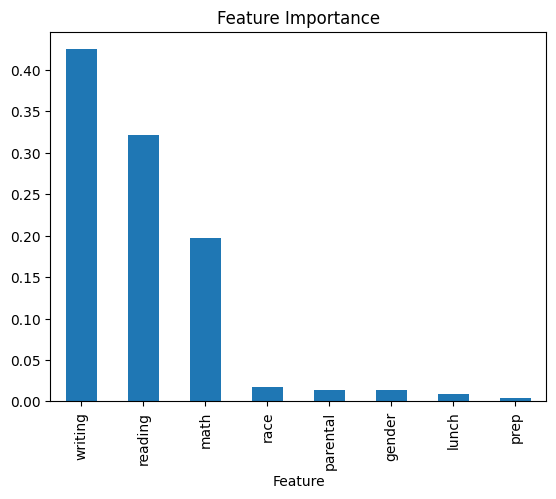

In [59]:
# Plot Graph
import matplotlib.pyplot as plt

importance_df.plot(
    kind='bar',
    x='Feature',
    y='Importance',
    legend=False
)

plt.title("Feature Importance")
plt.show()

In [95]:
# More Analysis
show_df(df.groupBy("gender").avg("average_score"))
show_df(df.groupBy("test preparation course").avg("average_score"))
show_df(df.groupBy("lunch").avg("average_score"))

,gender,avg(average_score)
0,female,69.569498
1,male,65.837483


,test preparation course,avg(average_score)
0,completed,72.669460
1,none,65.038941


,lunch,avg(average_score)
0,free/reduced,62.199061
1,standard,70.837209


In [96]:
#Average score by gender
show_df(df.groupBy("gender").avg("average_score"))


,gender,avg(average_score)
0,female,69.569498
1,male,65.837483


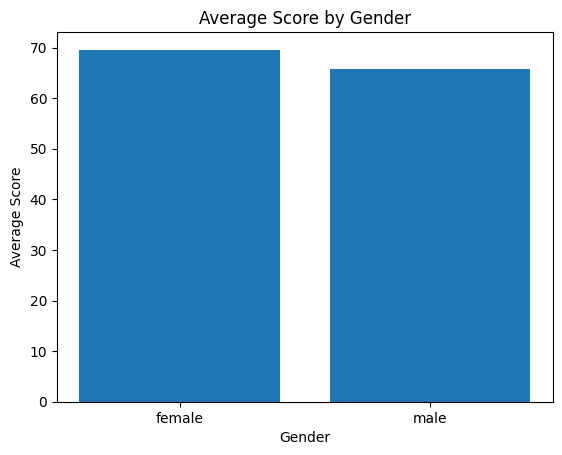

In [62]:
# its graph
import matplotlib.pyplot as plt

gender_df = df.groupBy("gender").avg("average_score").toPandas()

plt.bar(gender_df["gender"], gender_df["avg(average_score)"])
plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

In [97]:
# Impact of test preparation course
show_df(df.groupBy("test preparation course").avg("average_score"))

,test preparation course,avg(average_score)
0,completed,72.669460
1,none,65.038941


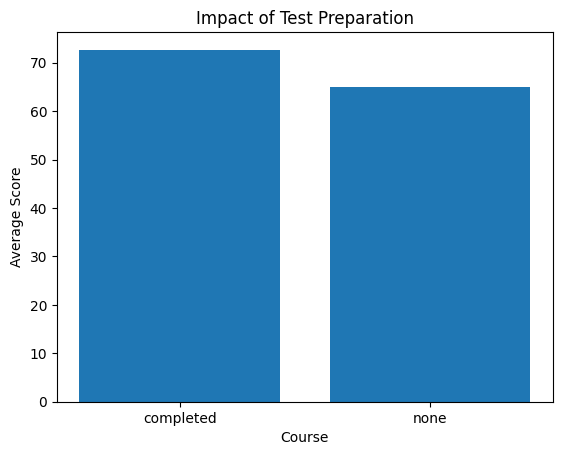

In [64]:
# its graph
prep_df = df.groupBy("test preparation course").avg("average_score").toPandas()

plt.bar(prep_df["test preparation course"], prep_df["avg(average_score)"])
plt.title("Impact of Test Preparation")
plt.xlabel("Course")
plt.ylabel("Average Score")
plt.show()

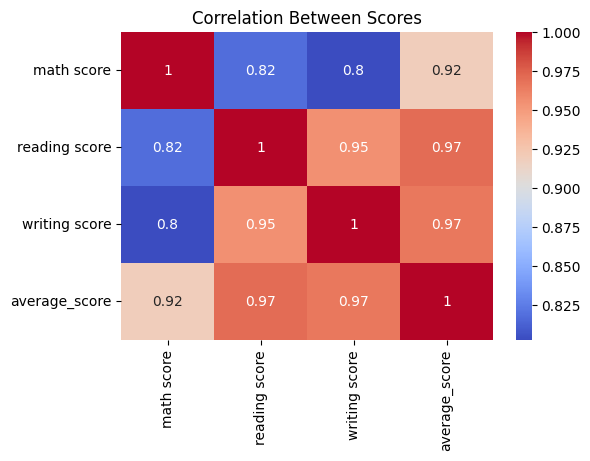

In [65]:
# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = df.select(
    "math score",
    "reading score",
    "writing score",
    "average_score"
).toPandas()

plt.figure(figsize=(6,4))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Scores")
plt.show()

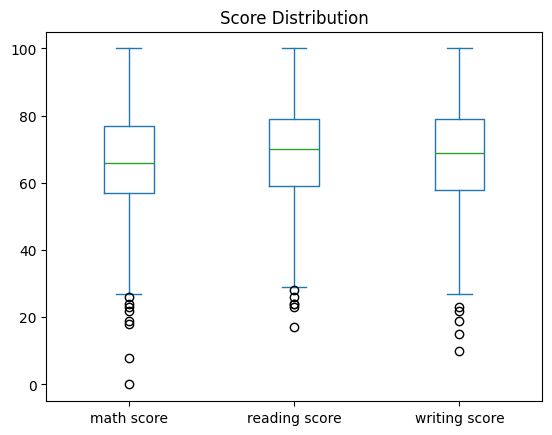

In [66]:
# Boxplot
scores_df = df.select(
    "math score",
    "reading score",
    "writing score"
).toPandas()

scores_df.plot(kind='box')
plt.title("Score Distribution")
plt.show()

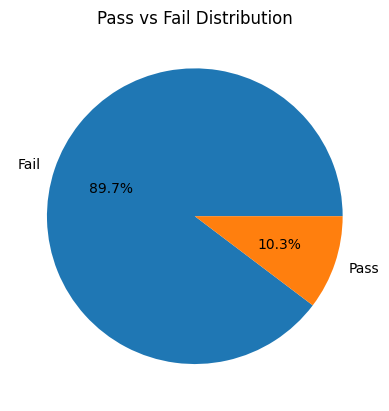

In [67]:
# Pie chart
pass_df = df.groupBy("pass").count().toPandas()

plt.pie(
    pass_df["count"],
    labels=["Fail", "Pass"],
    autopct='%1.1f%%'
)
plt.title("Pass vs Fail Distribution")
plt.show()

In [68]:
# Another Model - Logistic Regression
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="pass")
lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

accuracy_lr = evaluator.evaluate(lr_predictions)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9938271604938271


In [98]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="pass"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

show_df(lr_predictions.select("pass", "prediction"))

,pass,prediction
0,1,1.0
1,1,1.0
2,1,1.0
3,1,1.0
4,1,1.0


In [70]:
# Compare Models
print("Random Forest Accuracy:", accuracy)
print("Logistic Regression Accuracy:", accuracy_lr)

Random Forest Accuracy: 0.9876543209876543
Logistic Regression Accuracy: 0.9938271604938271


In [71]:
# Precision, Recall, F1 Score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="pass",
    predictionCol="prediction",
    metricName="f1"
)

f1_score = evaluator_f1.evaluate(predictions)

print("F1 Score:", f1_score)

F1 Score: 0.9873337840883479


In [72]:
# ROC Curve
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_roc = BinaryClassificationEvaluator(
    labelCol="pass",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

roc = evaluator_roc.evaluate(predictions)
print("ROC AUC:", roc)

ROC AUC: 0.9953703703703703


In [73]:
# Precision-Recall
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="pass",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="pass",
    predictionCol="prediction",
    metricName="weightedRecall"
)

print("Precision:", evaluator_precision.evaluate(predictions))
print("Recall:", evaluator_recall.evaluate(predictions))

Precision: 0.9878234398782344
Recall: 0.9876543209876543


In [99]:
# Prediction Example
show_df(predictions.select(
    "math score",
    "reading score",
    "writing score",
    "average_score",
    "pass",
    "prediction"
))

,math score,reading score,writing score,average_score,pass,prediction
0,65,85,76,75.333333,1,1.0
1,45,59,64,56.000000,1,1.0
2,59,72,70,67.000000,1,1.0
3,75,82,79,78.666667,1,1.0
4,61,60,57,59.333333,1,1.0


In [100]:
# What if scenario
new_data = spark.createDataFrame([
    (1.0, 2.0, 3.0, 0.0, 1.0, 40, 45, 42)
], [
    "gender_index",
    "race_index",
    "parental_index",
    "lunch_index",
    "prep_index",
    "math score",
    "reading score",
    "writing score"
])

new_data = assembler.transform(new_data)
show_df(model.transform(new_data))

,gender_index,race_index,parental_index,lunch_index,prep_index,math score,reading score,writing score,features,rawPrediction,probability,prediction
0,1.0,2.0,3.0,0.0,1.0,40,45,42,"[1.0, 2.0, 3.0, 0.0, 1.0, 40.0, 45.0, 42.0]","[48.59127525806781, 1.4087247419321811]","[0.9718255051613564, 0.028174494838643625]",0.0


In [78]:
# Steps to display All model accuracies together
# Step 1: Store Accuracies

accuracy_rf = accuracy          # Random Forest
accuracy_lr = accuracy_lr       # Logistic Regression

In [ ]:
# Step 2: Comparison Table
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [accuracy_rf, accuracy_lr]
})

model_comparison

,Model,Accuracy
0,Random Forest,0.987654
1,Logistic Regression,0.993827


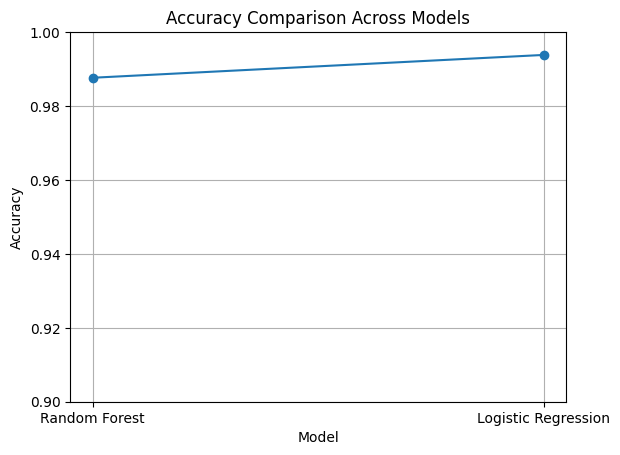

In [81]:
#Step 3: Line Comparison Graph
plt.plot(
    model_comparison["Model"],
    model_comparison["Accuracy"],
    marker='o',
    linestyle='-'
)

plt.title("Accuracy Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.9, 1.0)
plt.grid(True)

plt.show()


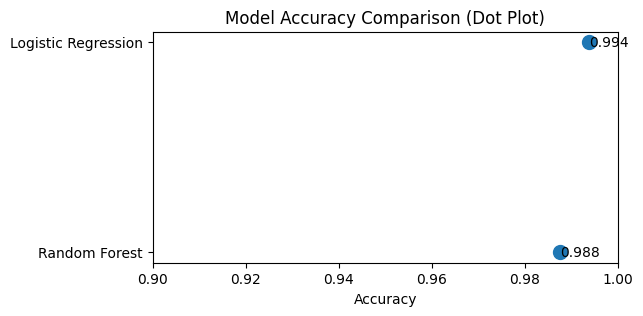

In [82]:
# Dot Plot 
plt.figure(figsize=(6,3))

plt.scatter(model_comparison["Accuracy"], model_comparison["Model"], s=100)

for i, txt in enumerate(model_comparison["Accuracy"]):
    plt.text(txt, i, f"{txt:.3f}", va='center')

plt.title("Model Accuracy Comparison (Dot Plot)")
plt.xlabel("Accuracy")

plt.xlim(0.9, 1.0)
plt.show()

In [101]:
# Final Output
print("Final Model Accuracy (Random Forest):", accuracy)
print("Final Model Accuracy (Logistic Regression):", accuracy_lr)

print("\nConclusion:")
print("Random Forest performed better and is selected as the final model.")

Final Model Accuracy (Random Forest): 0.9876543209876543
Final Model Accuracy (Logistic Regression): 0.9938271604938271

Conclusion:
Random Forest performed better and is selected as the final model.


This project successfully predicts student performance using machine learning techniques. Random Forest achieved the highest accuracy due to its ability to model complex relationships. Key factors affecting performance include academic scores and test preparation. The system can be scaled using Apache Spark for large datasets.